# Импорты
___


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


In [ ]:
style_content = """figure.facecolor: black
axes.facecolor: black
axes.edgecolor: white
axes.labelcolor: white
text.color: white
xtick.color: white
ytick.color: white
ytick.color: white
grid.color: gray
grid.alpha: 0.3
lines.color: white
patch.edgecolor: white
axes.prop_cycle: cycler('color', ['white', 'lightgray', 'silver', 'darkgray', 'gray'])"""

with open('black_white.mplstyle', 'w', encoding='utf-8') as f:
    f.write(style_content)

print("Файл стиля создан: black_white.mplstyle")

Файл стиля создан: black_white.mplstyle


In [ ]:
plt.style.use('./black_white.mplstyle')

print("Текущие стили:", plt.style.available[-5:])

Текущие стили: ['seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


# Загрузка данных
___

In [ ]:
name='df.csv'
df=pd.read_csv(name, sep=';')

In [ ]:
# plt.style.use('dark_background')


In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

# Предобработка
___

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df = df.replace('unknown', np.nan)

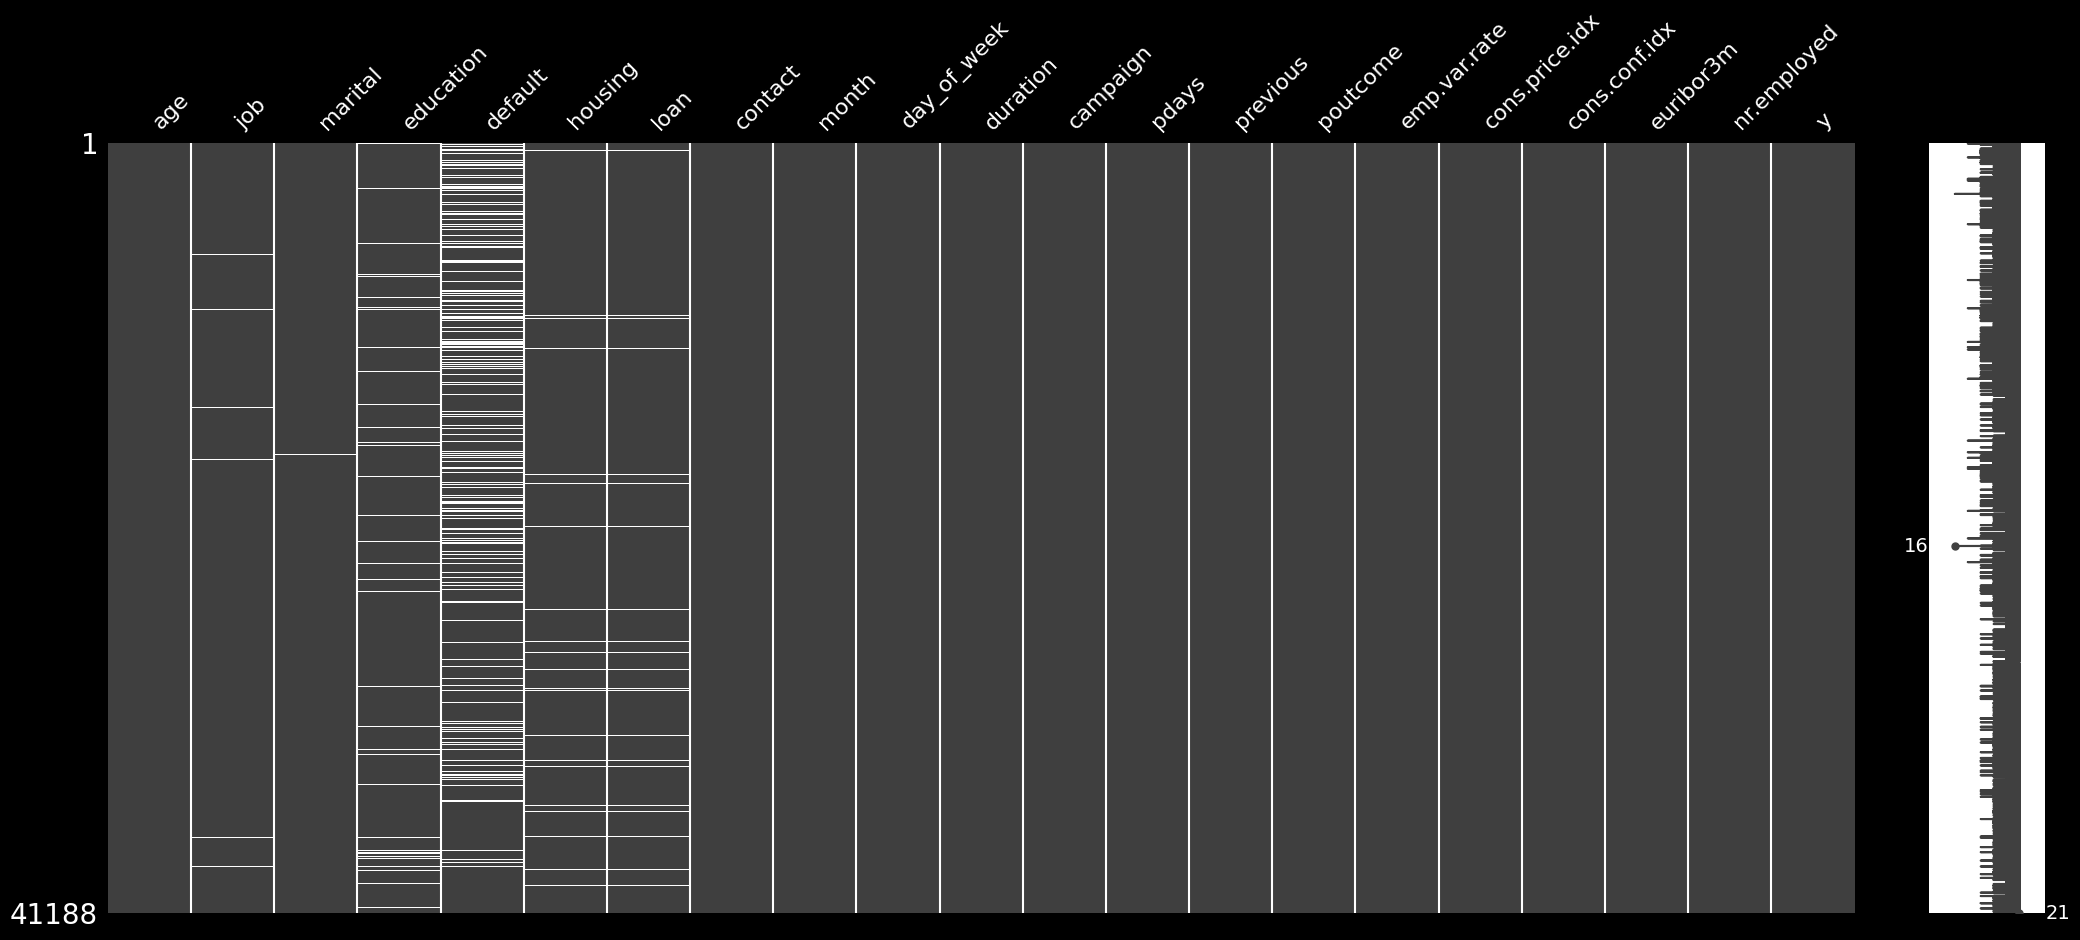

In [ ]:
import missingno as msno

msno.matrix(df)
plt.show()

In [ ]:
df = df.drop_duplicates()
df = df.loc[:, df.isna().mean() <= 0.3]
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
# df = df.dropna()

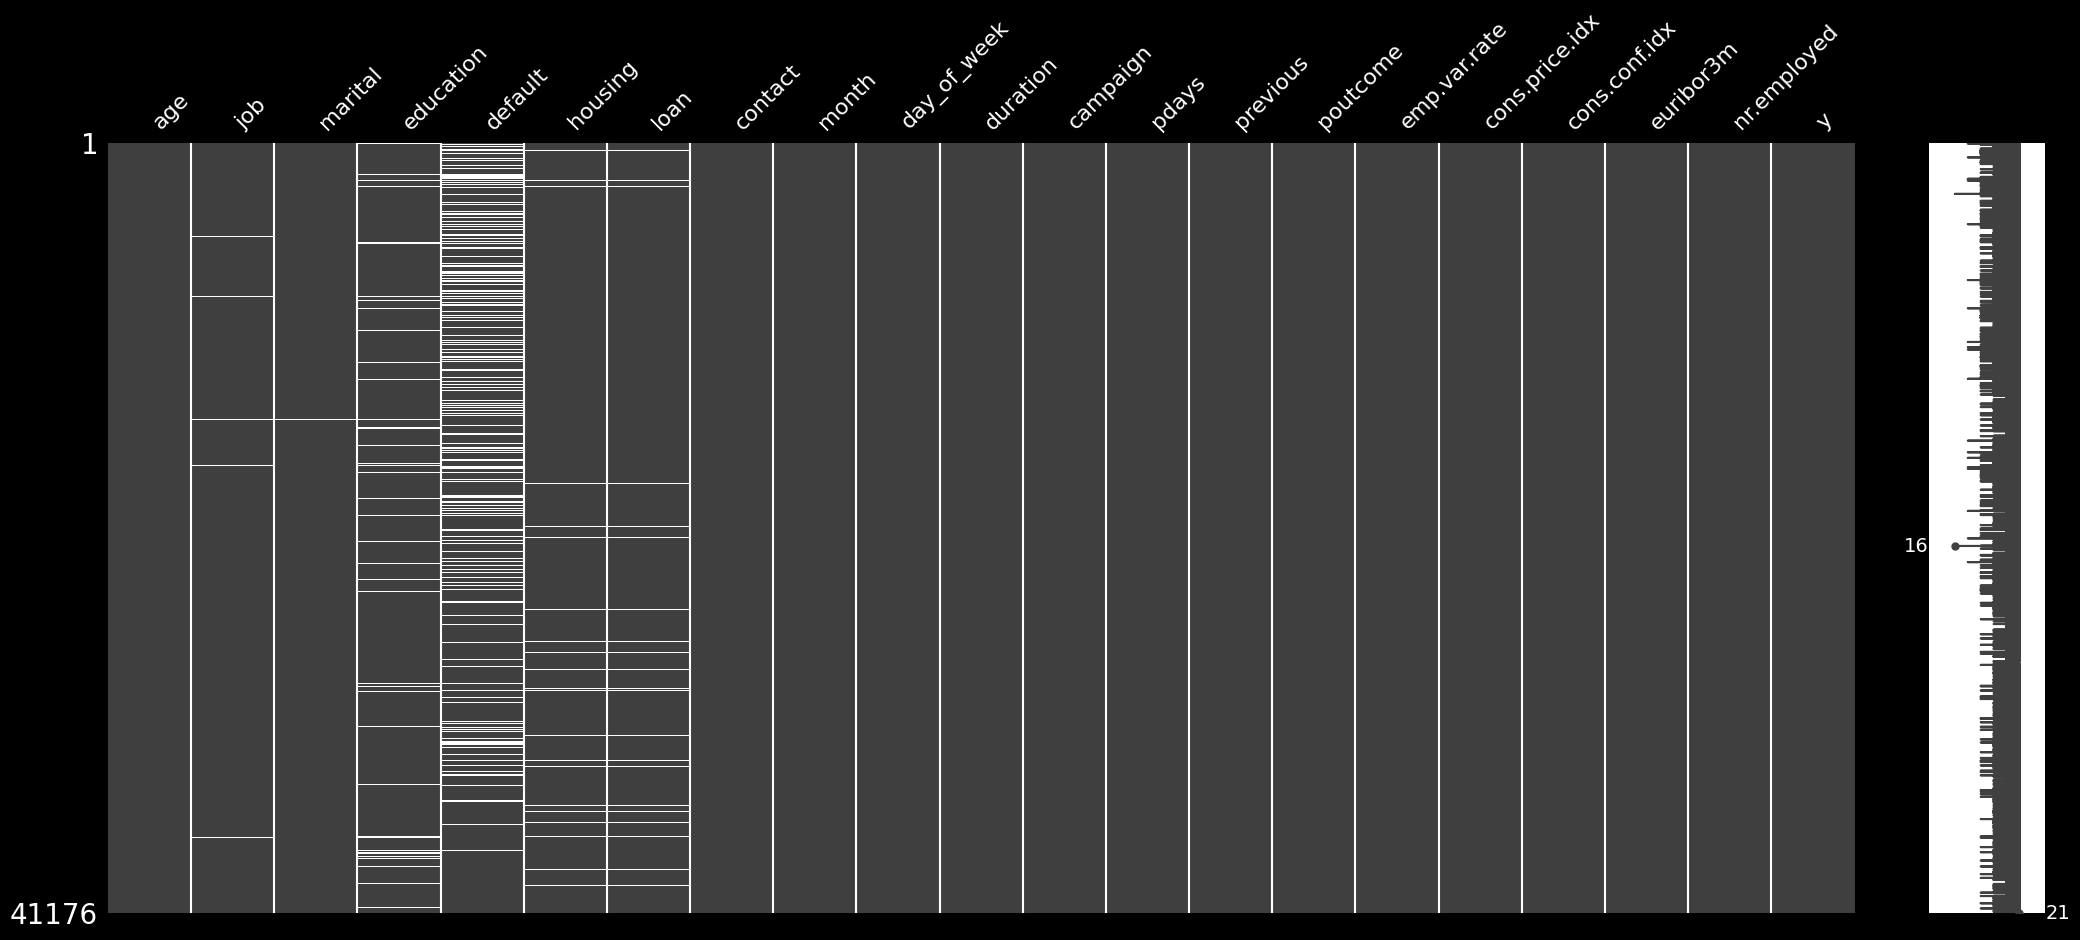

In [ ]:
msno.matrix(df)
plt.show()

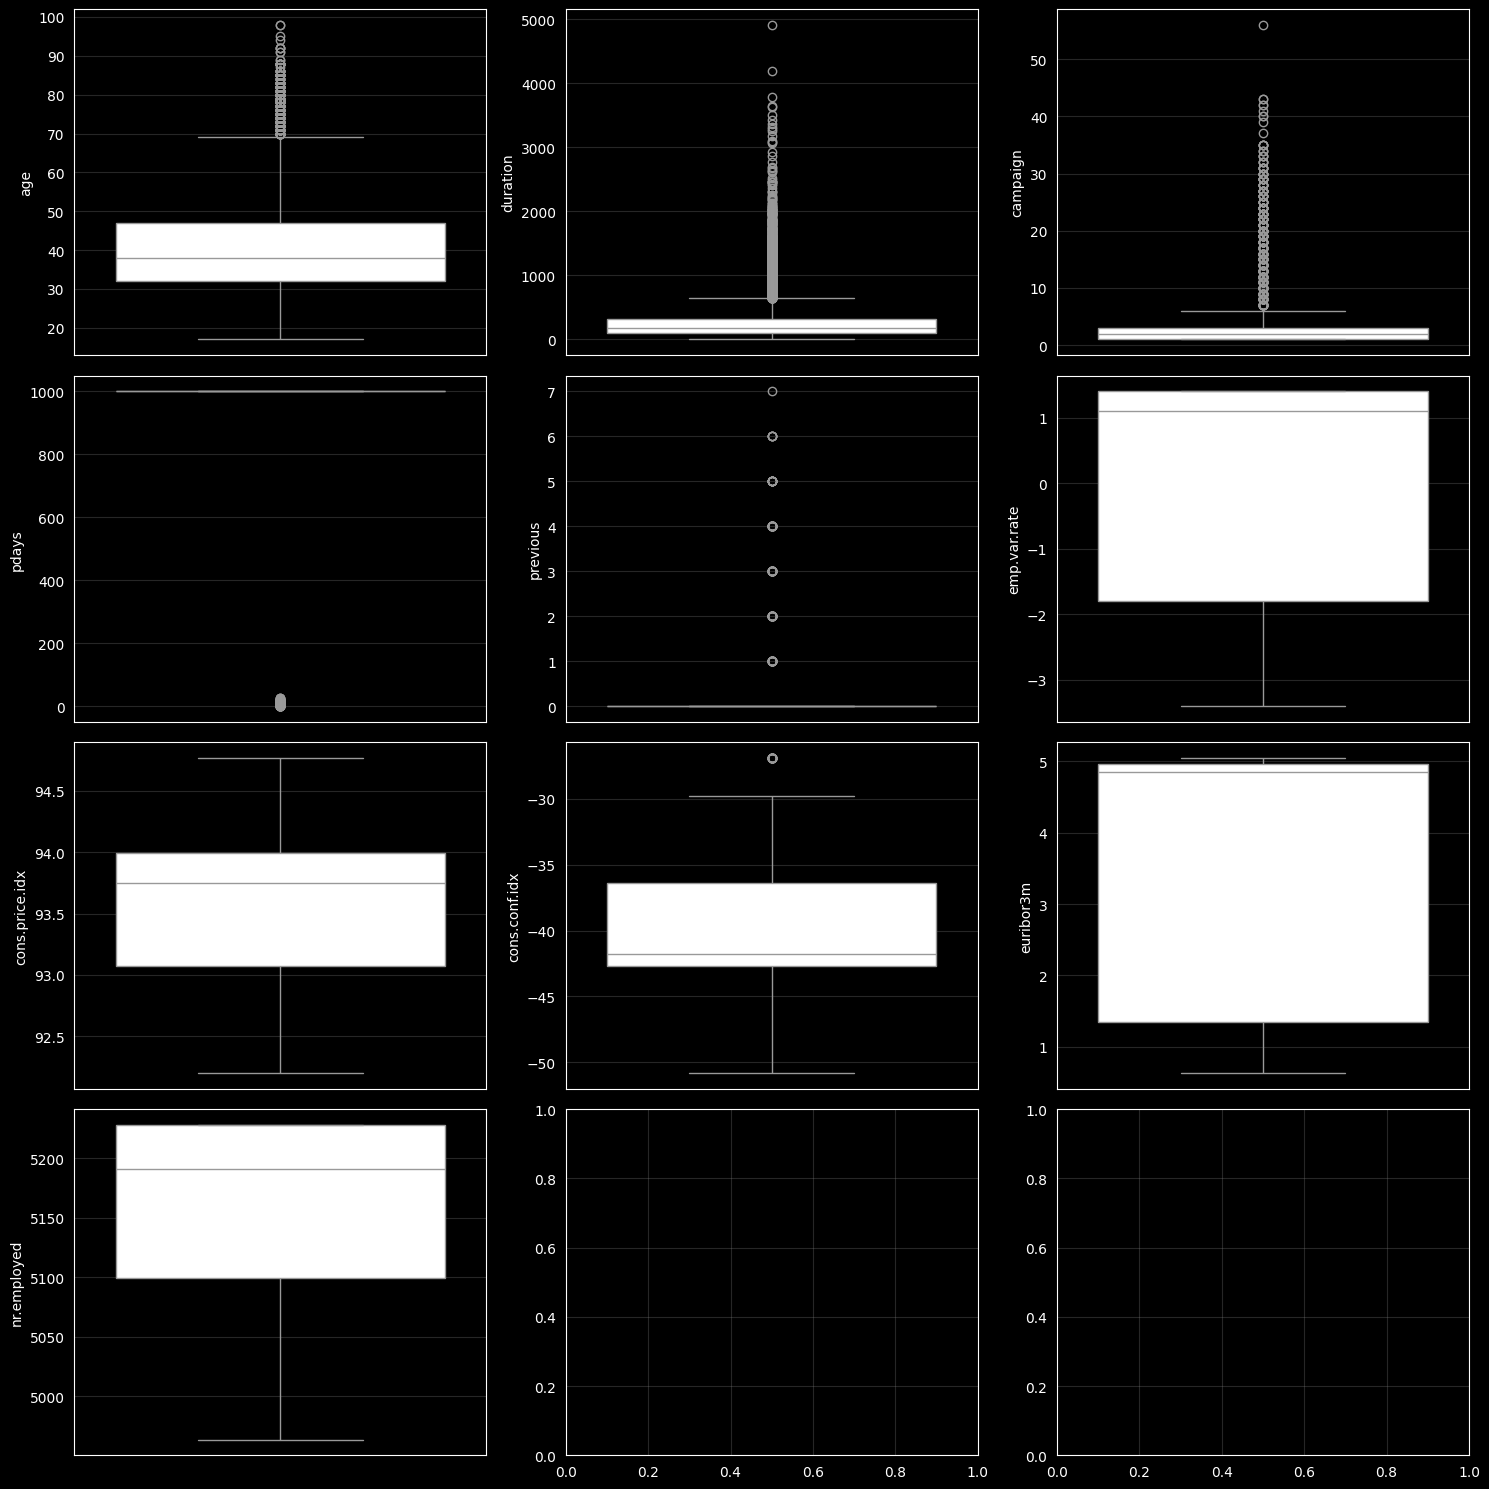

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(df.select_dtypes(include=["int64", "float64"]).columns):
    sns.boxplot(df[col], ax=axes[i])

plt.tight_layout()
plt.show()

# Аналитический блок
___

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


#### Распределения по переменным
___

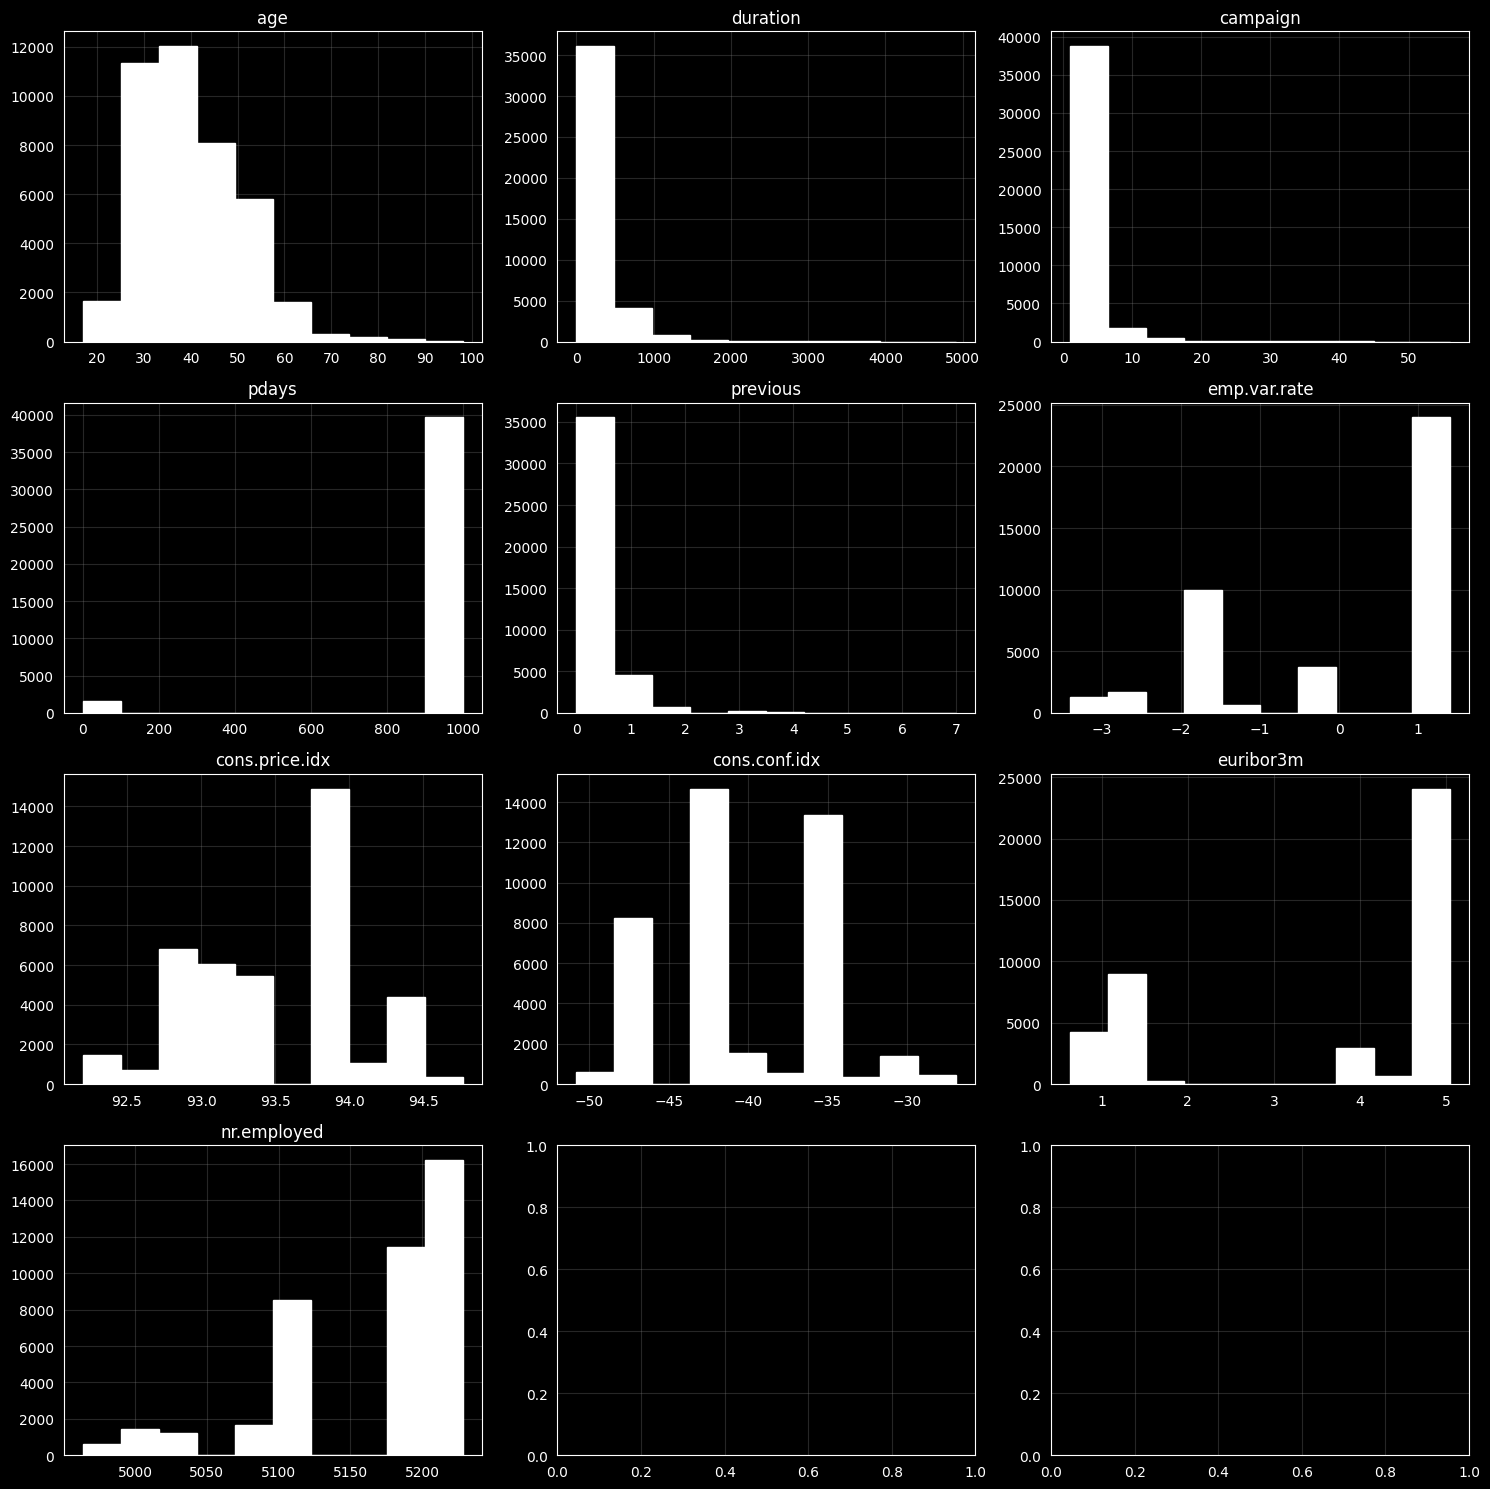

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(df.select_dtypes(include=["int64", "float64"]).columns):
    if i < len(axes):
        axes[i].hist(df[col].dropna())
        axes[i].set_title(col)

plt.tight_layout()
plt.show()

По графикам видно, что большая часть переменных не соответствует нормальному распределению

<Axes: >

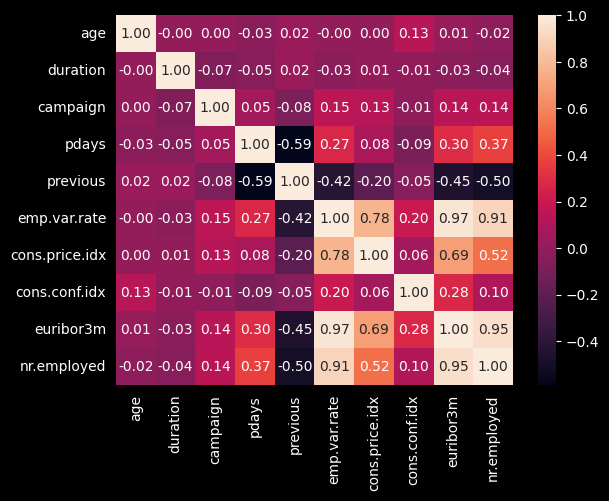

In [ ]:

sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f')

Быстрый анализ простой матрицы корелляций не дает какой то инсайдерской информации. Видно, что есть высокие корелляции, около 91% но это связано с тем что датасет имеет схожие значения

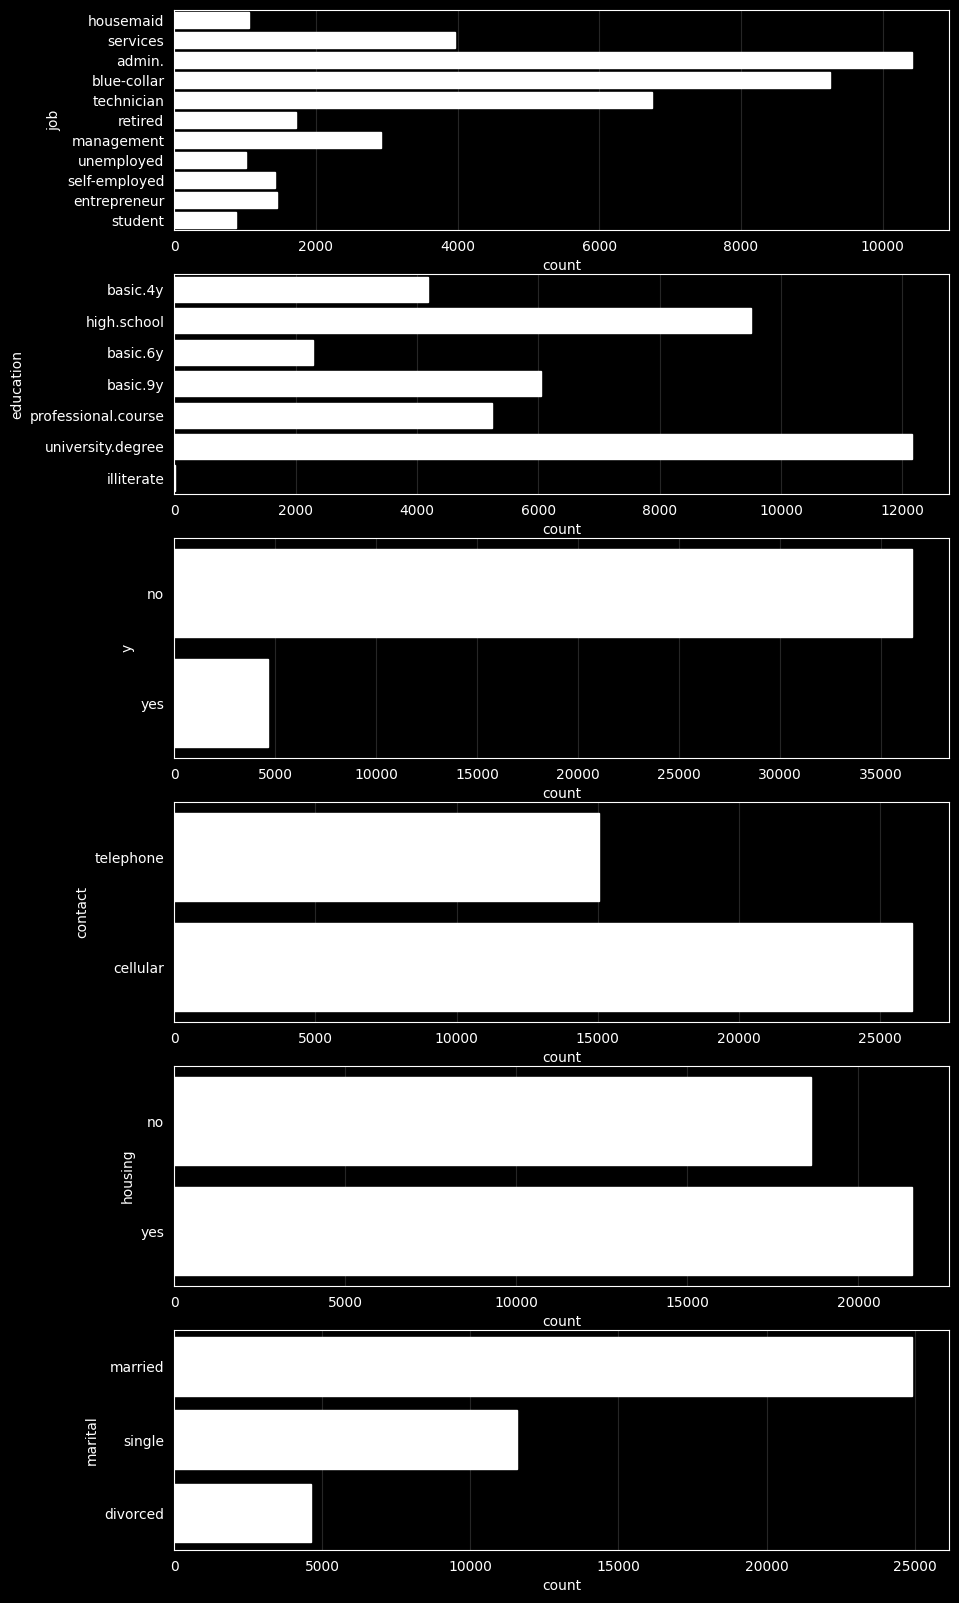

In [ ]:

fig, axes = plt.subplots (6, 1,figsize=(10, 20))
sns.set_style("darkgrid")
sns.countplot(y='job', data=df, ax=axes[0])
sns.countplot(y='education', data=df, ax=axes[1])
sns.countplot(y='y', data=df, ax=axes[2])
sns.countplot(y='contact', data=df, ax=axes[3])
sns.countplot(y='housing', data=df, ax=axes[4])
sns.countplot(y='marital', data=df, ax=axes[5])
plt.show()

- Самая распространенная область в профессии, в которой берут кредит - это администраторы.
- Самый распространенный уровень образования - высшее.
- Почти половина людей берут кредит на жилье, половина - на другие нужды.
- Женатых большая часть клиентов
- Мало тех, кто взял кредит в данном банке

##### Сравнение по месяцам как часто людям отказывали или одабривали кредит

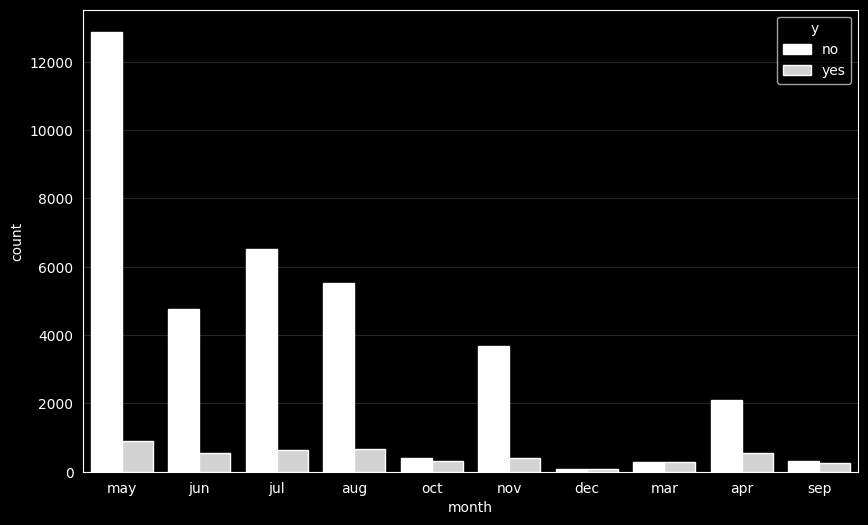

In [ ]:
plt.style.use('./black_white.mplstyle')

with sns.axes_style("dark", {"axes.facecolor": "black", "figure.facecolor": "black"}):
    plt.figure(figsize=(10, 6))
sns.countplot(x='month', hue='y', data=df)
plt.show()

По сравнительному анализу можно сказать что количество тех кто взял креди и отказался от него

Количество звонков не сильно влияет на количество взятых кредитов, возможно значимость другого фактора

# Рабочий блок
___

In [ ]:

from sklearn.model_selection import train_test_split
y = df['y']
X = df.drop(['y'], axis=1)



порядковые фичи в данных:  
education  


In [ ]:
df['education'].unique()

array(['basic.4y', 'high.school', 'basic.6y', 'basic.9y',
       'professional.course', nan, 'university.degree', 'illiterate'],
      dtype=object)

In [ ]:
nom_cols = ['education']

In [ ]:

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_cols = [
    col for col in X.select_dtypes(include=["object", "category"]).columns
    if col != "education"
]

# Создание Pipeline
___

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ("Imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

## Ординальный экнодер
___

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

edu_order = [
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree",
    "unknown"
]

ord_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ord", OrdinalEncoder(categories=[edu_order], handle_unknown="use_encoded_value", unknown_value=len(edu_order)))
])

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
    ("ord", ord_pipeline, nom_cols)
])

## Разделение на тренировочную и тестовую выборку (20/80)
___

In [ ]:
X_train, X_test, y_train,y_test = train_test_split(X,y,  test_size=0.2, random_state=42)
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['illiterate',
                                                                                               'basic.4y',
                                                                                               'basic.6y',
                                                                                               'basic.9y',
                                                                                               'high.school',
                                                                                               'professional.course',
                                                                                               'university.degree',
                                                                                               'unknown']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=8))]),
                                                  ['education'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## SGD модель
___

SGD accuracy: 0.8987
Accuracy:
sklearn: 0.8561
GD (SGD): 0.8987
Ансамбль: 0.8956

Оптимальный порог: 0.214

Порог 0.5:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      7265
           1       0.55      0.69      0.61       971

    accuracy                           0.90      8236
   macro avg       0.75      0.81      0.77      8236
weighted avg       0.91      0.90      0.90      8236


Оптимальный порог:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      7265
           1       0.38      0.95      0.55       971

    accuracy                           0.81      8236
   macro avg       0.69      0.87      0.71      8236
weighted avg       0.92      0.81      0.84      8236

Коэффициенты SGD модели: [[-0.11447126  1.40823259 -0.08948024 -0.30145031 -0.13017893 -2.09481776
   1.05990626  0.21029291  0.50485919 -0.02022168  0.16325934 -0.15898914
  -0.02434989  0.13738893 -0.14919

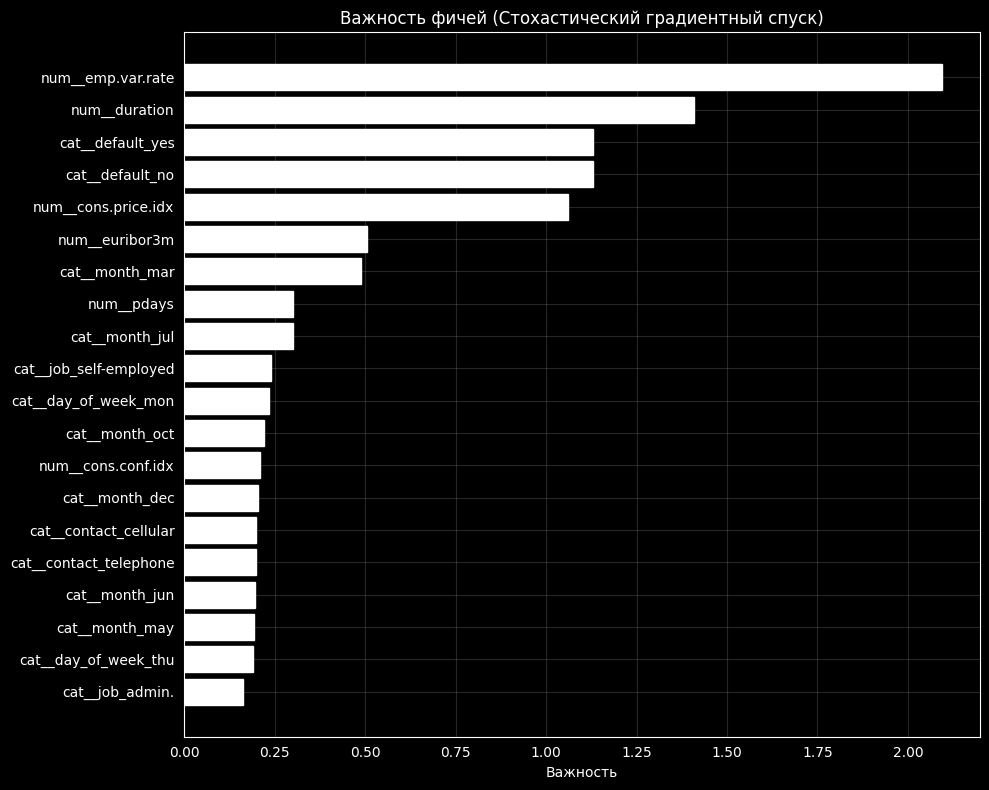

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

sgd_full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('sgd', SGDClassifier(
        loss='log_loss',
        penalty='l2',
        alpha=0.0001,
        learning_rate='constant',
        eta0=0.03,
        max_iter=200,
        tol=1e-4,
        random_state=42,
        verbose=0
    ))
])

sgd_full_pipeline.fit(X_train, y_train)

sgd_accuracy = sgd_full_pipeline.score(X_test, y_test)
print(f"SGD accuracy: {sgd_accuracy:.4f}")

y_gd_test = (y_test == 'yes').astype(int).values

y_pred_proba_sgd = sgd_full_pipeline.predict_proba(X_test)[:, 1]

y_pred_sgd = sgd_full_pipeline.predict(X_test)

sgd_model = sgd_full_pipeline.named_steps['sgd']

model_gd = sgd_full_pipeline

y_pred_proba_sklearn = model_pipeline.predict_proba(X_test)[:, 1]
y_pred_proba_gd = model_gd.predict_proba(X_test)[:, 1]

y_pred_proba_ensemble = 0.6 * y_pred_proba_sklearn + 0.4 * y_pred_proba_gd
y_test_bin = (y_test == 'yes').astype(int)

print("Accuracy:")
print(f"sklearn: {accuracy_score(y_test_bin, (y_pred_proba_sklearn > 0.5).astype(int)):.4f}")
print(f"GD (SGD): {accuracy_score(y_test_bin, (y_pred_proba_gd > 0.5).astype(int)):.4f}")
print(f"Ансамбль: {accuracy_score(y_test_bin, (y_pred_proba_ensemble > 0.5).astype(int)):.4f}")

fpr, tpr, thresholds = roc_curve(y_test_bin, y_pred_proba_ensemble)
opt_idx = np.argmax(tpr - fpr)
opt_thresh = thresholds[opt_idx]

print(f"\nОптимальный порог: {opt_thresh:.3f}")

print("\nПорог 0.5:")
print(classification_report(y_test_bin, (y_pred_proba_ensemble >= 0.5).astype(int)))

print("\nОптимальный порог:")
print(classification_report(y_test_bin, (y_pred_proba_ensemble >= opt_thresh).astype(int)))
print(f"Коэффициенты SGD модели: {sgd_model.coef_}")
print(f"Intercept: {sgd_model.intercept_}")

plt.figure(figsize=(10, 8))
plt.barh(sgd_importance['feature'][:20][::-1], sgd_importance['importance'][:20][::-1])
plt.xlabel('Важность')
plt.title('Важность фичей (Стохастический градиентный спуск)')
plt.tight_layout()
plt.show()

## Дерево решений
___

Дерево решений:
Порог: 0.465, Accuracy: 0.8315
              precision    recall  f1-score   support

           0       0.99      0.80      0.89      7265
           1       0.39      0.93      0.55       971

    accuracy                           0.82      8236
   macro avg       0.69      0.87      0.72      8236
weighted avg       0.92      0.82      0.85      8236



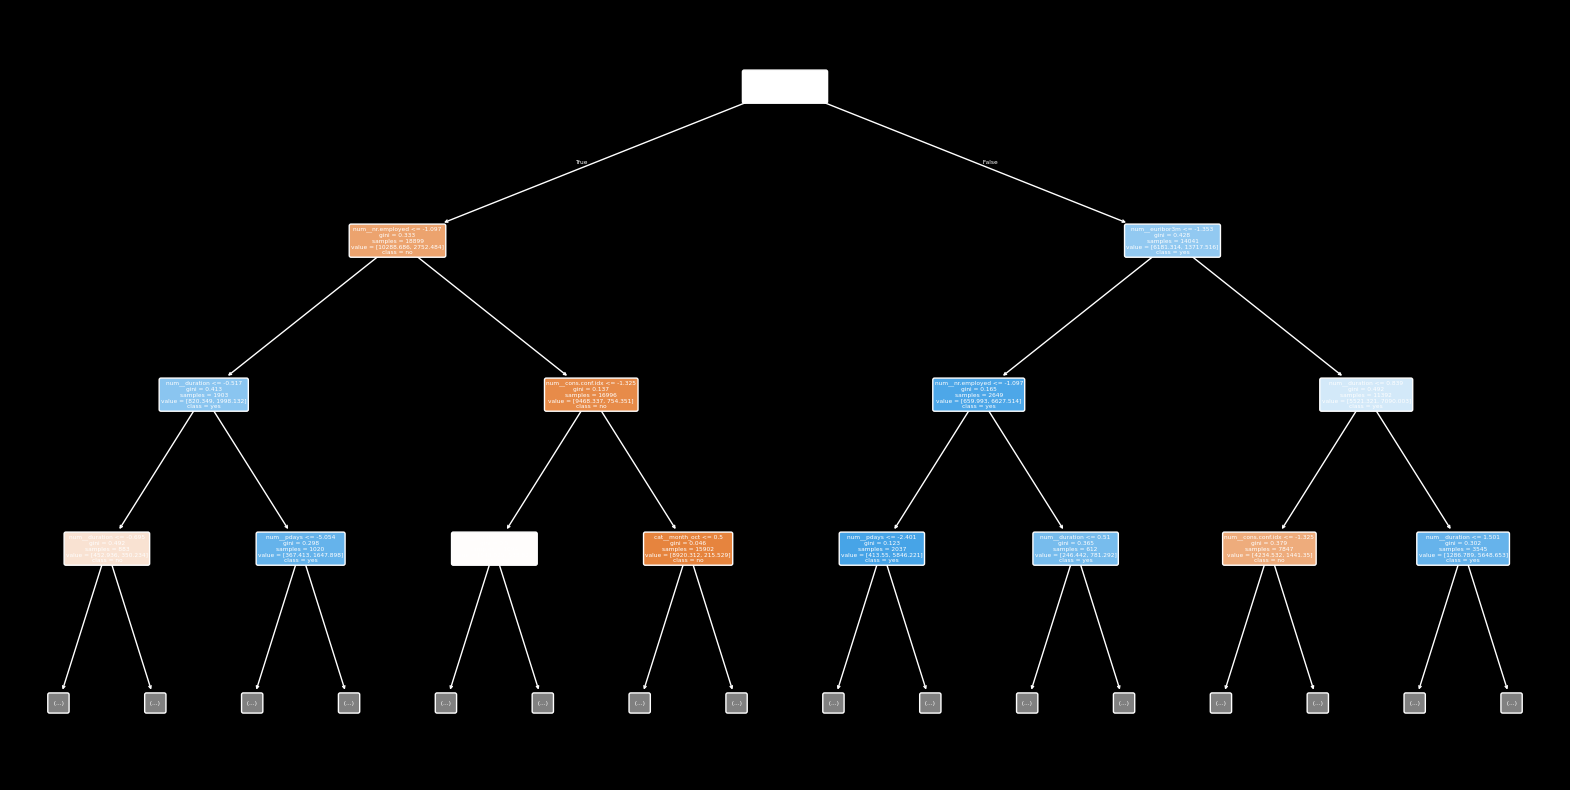


Топ-10 признаков:
                feature  importance
1         num__duration    0.584948
9      num__nr.employed    0.172733
8        num__euribor3m    0.115336
7    num__cons.conf.idx    0.100479
40       cat__month_oct    0.010846
3            num__pdays    0.010542
6   num__cons.price.idx    0.005116
2         num__campaign    0.000000
4         num__previous    0.000000
5     num__emp.var.rate    0.000000


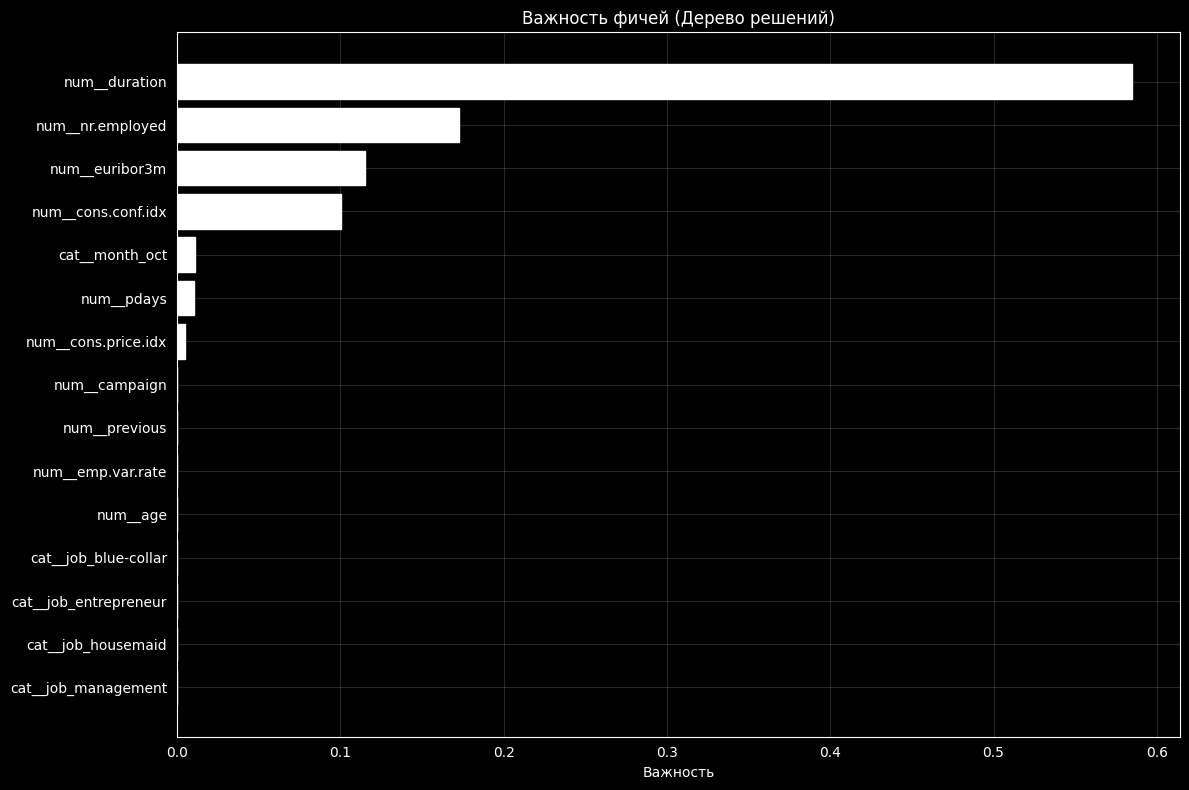

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_pipeline = Pipeline([
    ("preproc", preprocessor),
    ("clf", DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                   min_samples_leaf=5, class_weight='balanced',
                                   random_state=42))
])

tree_pipeline.fit(X_train, y_train)
y_pred_proba_tree = tree_pipeline.predict_proba(X_test)[:, 1]

fpr_tree, tpr_tree, thresh_tree = roc_curve(y_test_bin, y_pred_proba_tree)
opt_thresh_tree = thresh_tree[np.argmax(tpr_tree - fpr_tree)]

print("Дерево решений:")
print(f"Порог: {opt_thresh_tree:.3f}, Accuracy: {tree_pipeline.score(X_test, y_test):.4f}")
print(classification_report(y_test_bin, (y_pred_proba_tree >= opt_thresh_tree).astype(int)))

plt.figure(figsize=(20, 10))
feature_names = tree_pipeline.named_steps['preproc'].get_feature_names_out()
plot_tree(tree_pipeline.named_steps['clf'], feature_names=feature_names,
          class_names=['no', 'yes'], filled=True, rounded=True, max_depth=3)
plt.show()

tree_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': tree_pipeline.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 признаков:")
print(tree_importance.head(10))

plt.figure(figsize=(12, 8))
plt.barh(tree_importance['feature'][:15][::-1], tree_importance['importance'][:15][::-1])
plt.xlabel('Важность')
plt.title('Важность фичей (Дерево решений)')
plt.tight_layout()
plt.show()

## Случайный лес
___

Random Forest:
Порог: 0.463, Accuracy: 0.8561
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      7265
           1       0.43      0.93      0.59       971

    accuracy                           0.85      8236
   macro avg       0.71      0.88      0.75      8236
weighted avg       0.92      0.85      0.87      8236


Топ-10 важных признаков:
                  feature  importance
1           num__duration    0.435474
9        num__nr.employed    0.130830
8          num__euribor3m    0.092048
5       num__emp.var.rate    0.075408
7      num__cons.conf.idx    0.044546
6     num__cons.price.idx    0.031777
3              num__pdays    0.029310
0                num__age    0.014891
49  cat__poutcome_success    0.013373
38         cat__month_may    0.012951


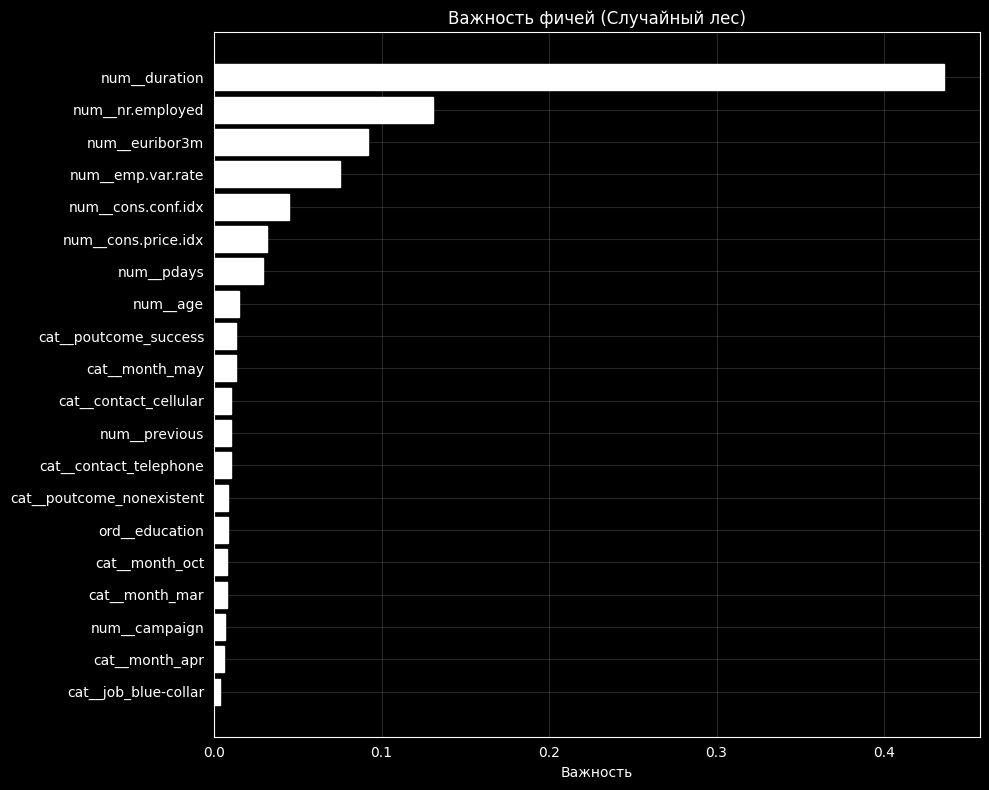

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preproc", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, max_depth=10,
                                  min_samples_split=10, min_samples_leaf=5,
                                  class_weight='balanced', random_state=42,
                                  n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresh_rf = roc_curve(y_test_bin, y_pred_proba_rf)
opt_thresh_rf = thresh_rf[np.argmax(tpr_rf - fpr_rf)]

print("Random Forest:")
print(f"Порог: {opt_thresh_rf:.3f}, Accuracy: {rf_pipeline.score(X_test, y_test):.4f}")
print(classification_report(y_test_bin, (y_pred_proba_rf >= opt_thresh_rf).astype(int)))

feature_names = rf_pipeline.named_steps['preproc'].get_feature_names_out()
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_pipeline.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(rf_importance.head(10))

plt.figure(figsize=(10, 8))
plt.barh(rf_importance['feature'][:20][::-1], rf_importance['importance'][:20][::-1])
plt.xlabel('Важность')
plt.title('Важность фичей (Случайный лес)')
plt.tight_layout()
plt.show()

## XGBOOST
___

XGBoost:
Порог: 0.412, Accuracy: 0.8534
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      7265
           1       0.44      0.94      0.60       971

    accuracy                           0.85      8236
   macro avg       0.72      0.89      0.76      8236
weighted avg       0.93      0.85      0.87      8236


Топ-10 признаков:
                  feature  importance
9        num__nr.employed    0.386465
7      num__cons.conf.idx    0.107332
1           num__duration    0.088246
5       num__emp.var.rate    0.049422
38         cat__month_may    0.032685
8          num__euribor3m    0.031723
40         cat__month_oct    0.030929
6     num__cons.price.idx    0.016836
49  cat__poutcome_success    0.015962
11   cat__job_blue-collar    0.015244


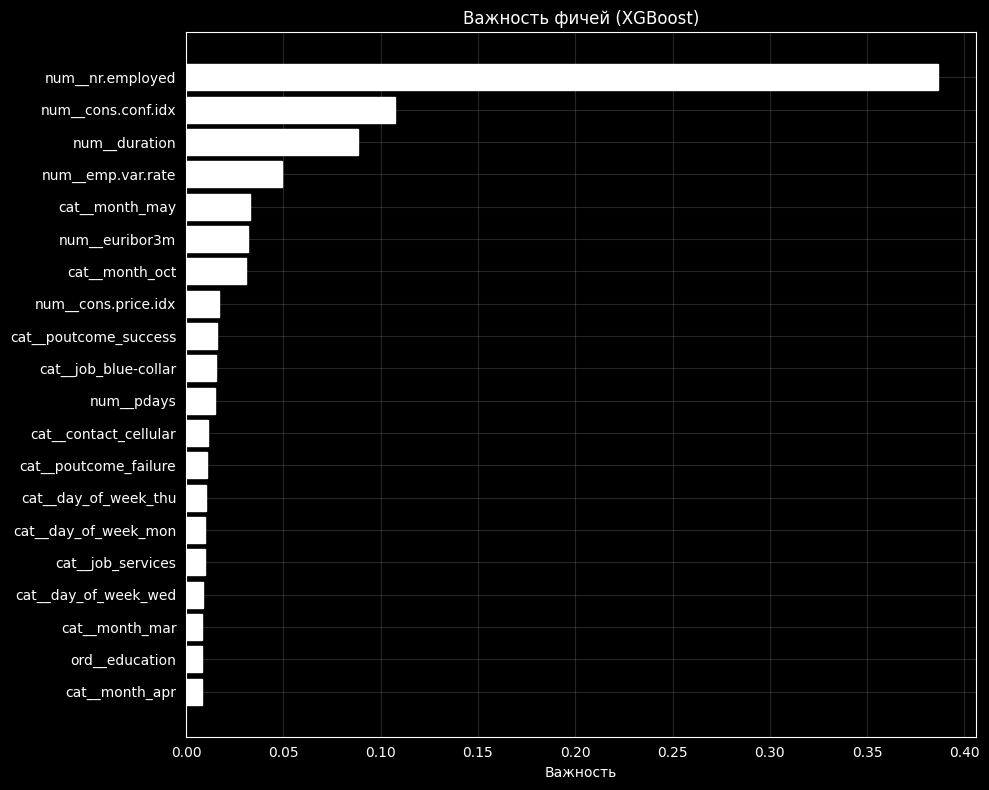

In [ ]:
import xgboost as xgb

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              random_state=42, n_jobs=-1,
                              scale_pos_weight=len(y_train[y_train=='no'])/len(y_train[y_train=='yes']))

xgb_model.fit(X_train_proc, y_train_enc, eval_set=[(X_test_proc, y_test_enc)], verbose=False)

y_pred_xgb = xgb_model.predict_proba(X_test_proc)[:, 1]
opt_thresh_xgb = roc_curve(y_test_enc, y_pred_xgb)[2][np.argmax(roc_curve(y_test_enc, y_pred_xgb)[1] - roc_curve(y_test_enc, y_pred_xgb)[0])]

print("XGBoost:")
print(f"Порог: {opt_thresh_xgb:.3f}, Accuracy: {accuracy_score(y_test_enc, (y_pred_xgb >= opt_thresh_xgb).astype(int)):.4f}")
print(classification_report(y_test_enc, (y_pred_xgb >= opt_thresh_xgb).astype(int)))

feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)


print("\nТоп-10 признаков:")
print(importance_df.head(10))

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:20][::-1], importance_df['importance'][:20][::-1])
plt.xlabel('Важность')
plt.title('Важность фичей (XGBoost)')
plt.tight_layout()
plt.show()

In [ ]:
print("Logistic Regression:")
print("Train score:", model_pipeline.score(X_train, y_train))
print("Test score:", model_pipeline.score(X_test, y_test))
print("-" * 40)

print("SGD Classifier:")
print("Train score:", sgd_full_pipeline.score(X_train, y_train))
print("Test score:", sgd_full_pipeline.score(X_test, y_test))
print("-" * 40)

print("Decision Tree:")
print("Train score:", tree_pipeline.score(X_train, y_train))
print("Test score:", tree_pipeline.score(X_test, y_test))
print("-" * 40)

print("Random Forest:")
print("Train score:", rf_pipeline.score(X_train, y_train))
print("Test score:", rf_pipeline.score(X_test, y_test))
print("-" * 40)

from sklearn.metrics import accuracy_score
y_train_pred_xgb = xgb_model.predict(X_train_proc)
y_test_pred_xgb = xgb_model.predict(X_test_proc)

print("XGBoost:")
print("Train score:", accuracy_score(y_train_enc, y_train_pred_xgb))
print("Test score:", accuracy_score(y_test_enc, y_test_pred_xgb))
print("-" * 40)



Logistic Regression:
Train score: 0.8625683060109289
Test score: 0.8561194754735308
----------------------------------------
SGD Classifier:
Train score: 0.9071341833636916
Test score: 0.8987372510927635
----------------------------------------
Decision Tree:
Train score: 0.837431693989071
Test score: 0.8314715881495872
----------------------------------------
Random Forest:
Train score: 0.8711293260473588
Test score: 0.8561194754735308
----------------------------------------
XGBoost:
Train score: 0.8807832422586521
Test score: 0.8678970373967946
----------------------------------------


Анализ Train/Test показывает хорошие результаты. Значение выше или равно 90%

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model_pipeline, X.astype(str), y.astype(str), cv=5)
print(f"CV accuracy: {cv_scores.mean():.4f}")

CV accuracy: 0.6870


## Логистическая регрессия
___

Logistic Regression порог: 0.391, Accuracy: 0.8315
              precision    recall  f1-score   support

          no       0.99      0.82      0.90      7265
         yes       0.41      0.93      0.57       971

    accuracy                           0.83      8236
   macro avg       0.70      0.87      0.73      8236
weighted avg       0.92      0.83      0.86      8236

Топ-20 самых важных фичей:
                   feature  importance      coef
5        num__emp.var.rate    3.234330 -3.234330
37          cat__month_mar    1.881629  1.881629
1            num__duration    1.830461  1.830461
6      num__cons.price.idx    1.216741  1.216741
38          cat__month_may    1.056594 -1.056594
8           num__euribor3m    1.047279  1.047279
36          cat__month_jun    1.001434 -1.001434
39          cat__month_nov    0.800290 -0.800290
33          cat__month_aug    0.797089  0.797089
47   cat__poutcome_failure    0.605789 -0.605789
15        cat__job_retired    0.425600  0.425600
49   ca

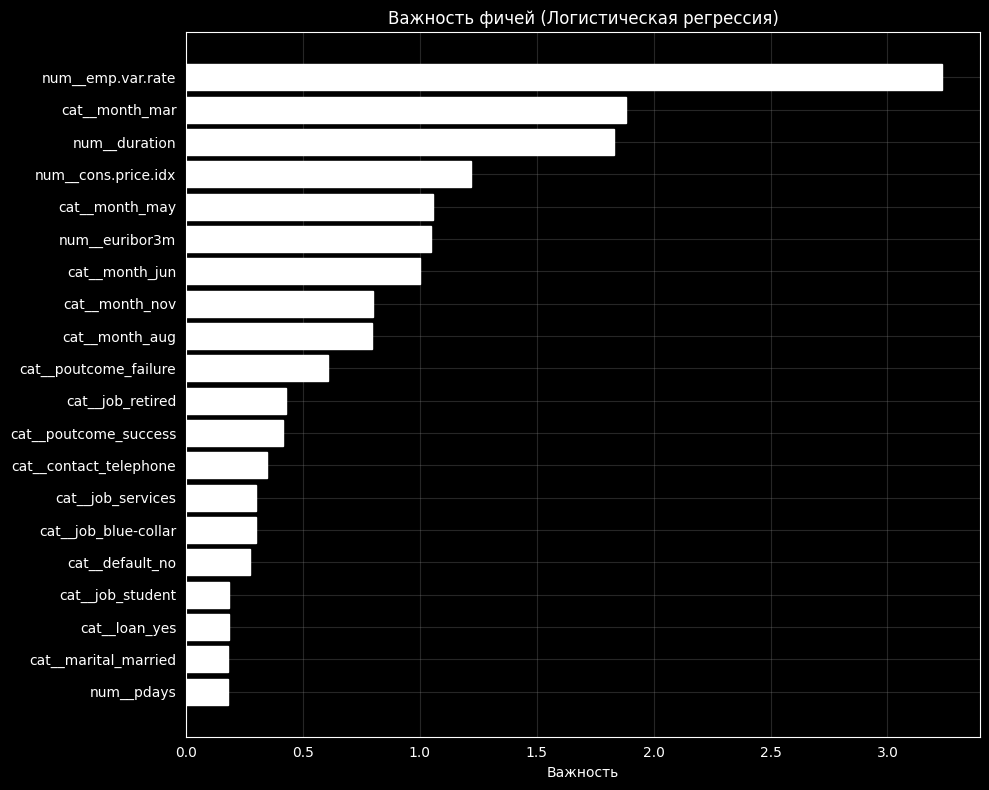

In [ ]:
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline([
    ("preproc", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

model_pipeline.fit(X_train, y_train)
coefficients = model_pipeline.named_steps['clf'].coef_[0]

feature_names = model_pipeline.named_steps['preproc'].get_feature_names_out()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': np.abs(coefficients),
    'coef': coefficients
})

feature_importance = feature_importance.sort_values('importance', ascending=False)

y_pred_proba_lr = model_pipeline.predict_proba(X_test)[:, 1]
y_test_bin = (y_test == 'yes').astype(int)

fpr_lr, tpr_lr, thresh_lr = roc_curve(y_test_bin, y_pred_proba_lr)
opt_thresh_lr = thresh_lr[np.argmax(tpr_lr - fpr_lr)]
y_pred_opt_lr = (y_pred_proba_lr >= opt_thresh_lr).astype(int)

print(f"Logistic Regression порог: {opt_thresh_lr:.3f}, Accuracy: {accuracy_score(y_test_bin, y_pred_opt_lr):.4f}")
print(classification_report(y_test_bin, y_pred_opt_lr, target_names=['no', 'yes']))

print("Топ-20 самых важных фичей:")
print(feature_importance.head(20))

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:20][::-1],
         feature_importance['importance'][:20][::-1])
plt.xlabel('Важность')
plt.title('Важность фичей (Логистическая регрессия)')
plt.tight_layout()
plt.show()

### Формула логистической регрессии
$$
P(yes) = \frac{1}{1 + e^{-P}},
$$ где$$
P = -0.7997 - 2.6285 \cdot x_{emp\_var\_rate\_std} + 1.6912 \cdot x_{mar} + 1.2045 \cdot x_{duration\_std} + 1.1466 \cdot x_{cons\_price\_idx\_std} - 0.8101 \cdot x_{may} - 0.7363 \cdot x_{nov} - 0.7103 \cdot x_{jun} + 0.7078 \cdot x_{euribor3m\_std} - 0.6343 \cdot x_{telephone} - 0.6196 \cdot x_{failure} - 0.5917 \cdot x_{default\_no} + 0.5410 \cdot x_{aug} - 0.3174 \cdot x_{loan\_yes} - 0.3134 \cdot x_{housing\_yes} - 0.3010 \cdot x_{apr} - 0.3009 \cdot x_{housing\_no} - 0.2969 \cdot x_{loan\_no} - 0.2808 \cdot x_{mon} - 0.2736 \cdot x_{self\_employed} - 0.2451 \cdot x_{blue\_collar}
$$

## Поиск гиперпараметров (GridSearchCV / RandomizedSearchCV)
____

In [ ]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(model_pipeline, {'clf__C': [0.01, 0.1, 1, 10, 100]}, cv=5, scoring='accuracy')
search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_test_bin = (y_test == 'yes').astype(int)

fpr, tpr, thresholds = roc_curve(y_test_bin, y_pred_proba)
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print(f"Лучший C: {search.best_params_['clf__C']}")
print(f"Лучшая CV точность: {search.best_score_:.4f}")
print(f"Оптимальный порог: {optimal_threshold:.3f}")
print(classification_report(y_test_bin, y_pred_optimal, target_names=['no', 'yes']))

Лучший C: 10
Лучшая CV точность: 0.8626
Оптимальный порог: 0.338
              precision    recall  f1-score   support

          no       0.99      0.80      0.88      7265
         yes       0.39      0.95      0.55       971

    accuracy                           0.82      8236
   macro avg       0.69      0.87      0.72      8236
weighted avg       0.92      0.82      0.85      8236



In [ ]:
search = GridSearchCV(model_pipeline, {'clf__C': [0.1, 1, 10]}, cv=3)
search.fit(X_train, y_train)

coef = search.best_estimator_.named_steps['clf'].coef_[0]
top_20_idx = np.argsort(np.abs(coef))[-20:]

from sklearn.preprocessing import FunctionTransformer
pipeline_top20 = Pipeline([
    ("preproc", preprocessor),
    ("selector", FunctionTransformer(lambda X: X[:, top_20_idx])),
    ("clf", LogisticRegression(max_iter=1000, C=search.best_params_['clf__C']))
])

pipeline_top20.fit(X_train, y_train)
print(f"Топ-20 фичей, test score: {pipeline_top20.score(X_test, y_test):.4f}")

Топ-20 фичей, test score: 0.9046


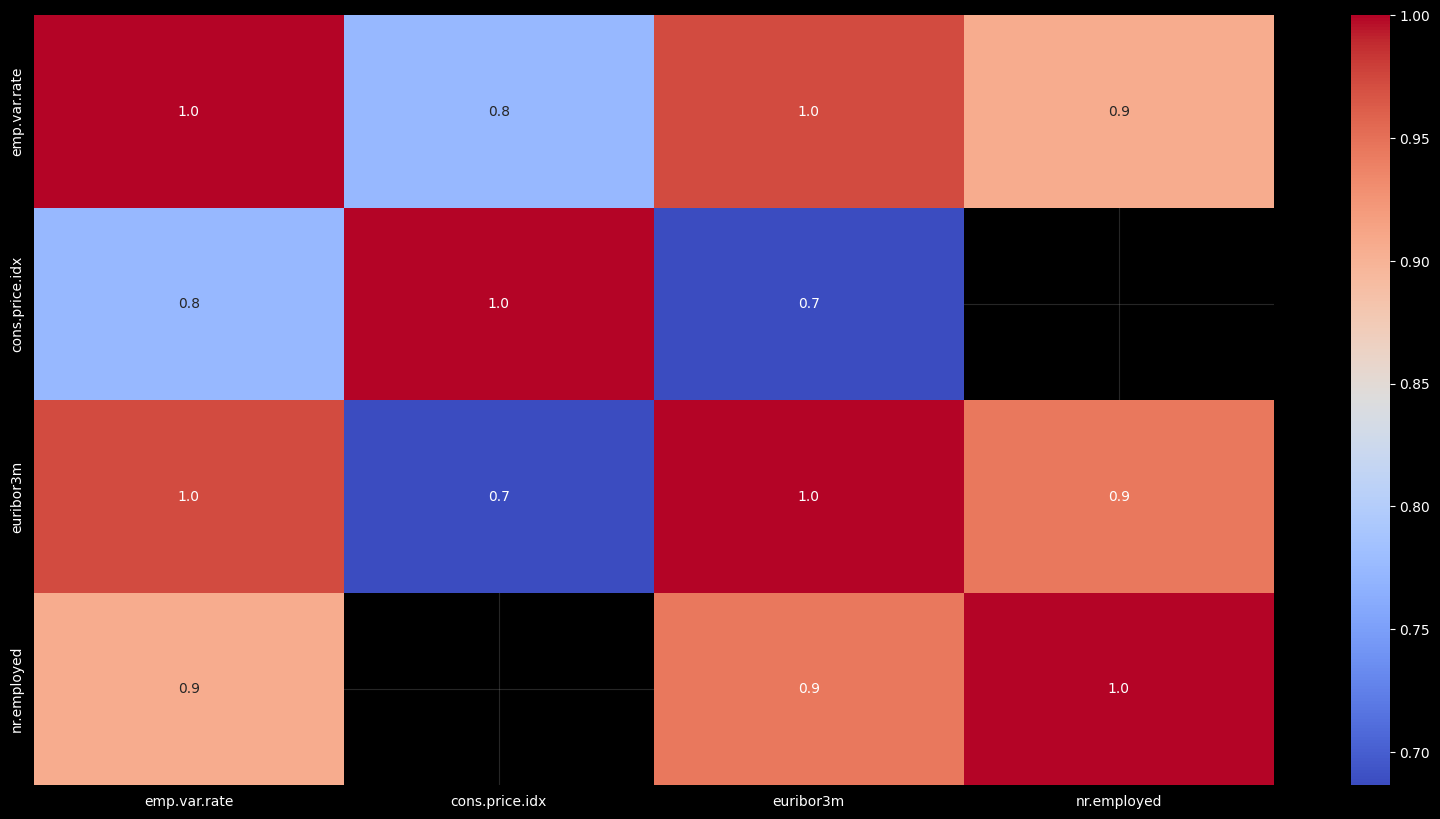

In [ ]:
fig,ax = plt.subplots(figsize=(20,10))

c = X_train.corr(numeric_only=True)
s = [col for col in c.columns if (c[col].drop(col).abs() > 0.6).any()]
sns.heatmap(c.loc[s, s], mask=(c.loc[s, s].abs() <= 0.6), annot=True, fmt='.1f', cmap='coolwarm')
plt.show()


## ROC/AUC
___

AUC: 0.9328


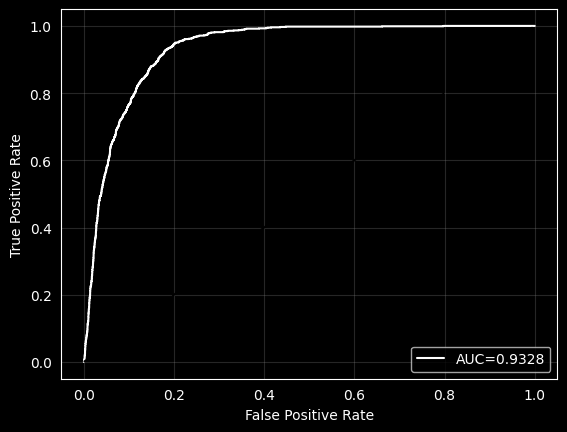

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ROC/AUC
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
y_test_binary = (y_test == 'yes').astype(int)

auc_score = roc_auc_score(y_test_binary, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test_binary, y_pred_proba)

print(f"AUC: {auc_score:.4f}")

plt.plot(fpr, tpr, label=f'AUC={auc_score:.4f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Выводы
___

Виден высокий показатель

In [ ]:
print("Balance check for target 'y':")
print(df['y'].value_counts())
print("\nPercentages:")
print(round(df['y'].value_counts(normalize=True) * 100, 2))

Balance check for target 'y':
y
no     36537
yes     4639
Name: count, dtype: int64

Percentages:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


In [ ]:

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_test_bin = (y_test == 'yes').astype(int)

print(f"{'Модель':<30} {'Acc':<6} {'Prec':<6} {'Rec':<6} {'F1':<6}")
print("-"*60)

predictions = {
    "Logistic Reg (opt)": y_pred_opt,
    "Logistic Reg (0.5)": (model_pipeline.predict_proba(X_test)[:, 1] >= 0.5).astype(int),
    "Decision Tree": (y_pred_proba_tree >= opt_thresh_tree).astype(int),
    "Random Forest": (y_pred_proba_rf >= opt_thresh_rf).astype(int),
    "XGBoost": (y_pred_xgb >= opt_thresh_xgb).astype(int),
    "SGD": (sgd_full_pipeline.predict(X_test) == 'yes').astype(int),
    "Ensemble (opt)": (y_pred_proba_ensemble >= opt_thresh).astype(int),
    "Ensemble (0.5)": (y_pred_proba_ensemble >= 0.5).astype(int)
}

for name, pred in predictions.items():
    acc = accuracy_score(y_test_bin, pred)
    prec = precision_score(y_test_bin, pred, zero_division=0)
    rec = recall_score(y_test_bin, pred, zero_division=0)
    f1 = f1_score(y_test_bin, pred, zero_division=0)
    print(f"{name:<30} {acc:.4f} {prec:.4f} {rec:.4f} {f1:.4f}")

Модель                         Acc    Prec   Rec    F1    
------------------------------------------------------------
Logistic Reg (opt)             0.8315 0.4061 0.9289 0.5652
Logistic Reg (0.5)             0.8561 0.4440 0.8733 0.5887
Decision Tree                  0.8178 0.3869 0.9341 0.5472
Random Forest                  0.8487 0.4341 0.9320 0.5923
XGBoost                        0.8534 0.4429 0.9423 0.6026
SGD                            0.8987 0.6252 0.3522 0.4506
Ensemble (opt)                 0.8129 0.3822 0.9526 0.5456
Ensemble (0.5)                 0.8956 0.5450 0.6921 0.6098


# Выбор модели для решения бизнес задач


Бизнес задача перед моделью - найти наибольшее число покупателей. Показатель качества определения y как yes - recall.  
Наибольший recall наблюдается у Ensemble (opt) = 0.9526..
Однако, также важно, чтобы ложно-положительные срабатывания не нагружали сотрудников банка. Показатель Precision у Ensemble (opt) = 0.3822, что очень мало.  
Оптимальная по соотношению recall и Precision модель :

XGBoost recall =  0.4429 и Precision = 0.8534,  
Способность к правильному определению потенциального клиента по прежнему высока, но ложно положительная ошибка ниже. Кроме того, важно, что F1 = 0.6026, что свидетельствует о лучшем балансе между Precision и Recall.

Если нужен максимальный охват yes (минимальное количество пропусков), выбираем Ensemble (opt).  
Если важен баланс между recall и precision, лучше XGBoost (F1 выше).

# Оценка весов и выводы

Intercept = -3.743 — это лог-ит при всех нулевых фичах. Отрицательный intercept означает, что при средних/нулевых значениях фичей модель склонна предсказывать класс "no"

num_euribor3m (-2.095) — самый сильный предиктор, снижающий вероятность "yes" при росте.  
ставка Euribor на 3 месяца — ежедневный показатель (числовой)
Европейская ставка межбанковского кредитования, отражает стоимость заемного капитала в евро. Изменения ставки могут указывать на тенденции в кредитовании и финансировании.  
Чем больше ставка, тем меньше шанс, что клиенты захотят сделать вклад.

num_duration (1.408) — второй по важности, увеличивает вероятность "yes"  
продолжительность последнего контакта в секундах. Чем дольше удержание клиента, тем больше вероятность, что он задумается о вкладе.

cat_default_yes (1.12892432) - наличие просроченного кредита увеличивает вероятность, что он задумается о вкладе.

cat_default_no (-1.12892432) - отсутствие просроченного кредита уменьшает вероятность, что он задумается о вкладе.

num_cons.price.idx: (1.05990626	) — индекс цен потребителей: рост повышает вероятность "yes".
индекс потребительских цен — ежемесячный показатель (числовой)
Изменение цен на корзину потребительских товаров и услуг. ИПЦ используется для оценки инфляции и покупательной способности населения.



Отрицательный вес num_cons.price.idx (-0.13) экономически обоснован:

Инфляция снижает реальные доходы → меньше денег на вклады.

Вклады теряют привлекательность при высокой инфляции.

Повышается осторожность потребителей.